<a href="https://colab.research.google.com/github/Magar-Bhuwan/ML-Internship-Assignments/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


The action playbook starts from the validated baseline action-score output created in ML-07.

The baseline prioritizes content using two observed signals: `days_since_last_update` and `impressions_90d`. Content that is at least 104 days since its last update and has at least 3,616 impressions in the last 90 days receives the highest-priority `review` action.

The purpose of the ranked queue is to help a human reviewer decide which content deserves attention first. Higher scores indicate higher priority under this rule; they do not guarantee that a refresh or other intervention will improve future performance.

The reason codes make the recommendation understandable:

* `stale_and_visible` — the content is both stale and visible under the validated thresholds.
* `stale` — the content is stale but does not meet the visibility threshold.
* `visible` — the content meets the visibility threshold but is not stale.
* `no_strong_signal` — neither baseline signal is present.

The baseline actions are:

* `review` — prioritize the item for human review.
* `monitor` — do not prioritize immediate intervention, but retain the item for monitoring.


In [45]:
!git clone https://github.com/Magar-Bhuwan/ML-Internship-Assignments.git

fatal: destination path 'ML-Internship-Assignments' already exists and is not an empty directory.


In [76]:
import pandas as pd

baseline_queue = pd.read_csv(
    "ML-Internship-Assignments/work/outputs/baseline_action_score.csv"
)

print("Columns:", baseline_queue.columns.tolist())
print("Shape:", baseline_queue.shape)

display(baseline_queue.head(20))

Columns: ['rank', 'content_id', 'days_since_last_update', 'impressions_90d', 'score', 'reason_code', 'action']
Shape: (30000, 7)


,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,104,517715,517715,stale_and_visible,review
1,2,content_2dba2b1f9536,104,443434,443434,stale_and_visible,review
2,3,content_2c2606c5d176,104,347399,347399,stale_and_visible,review
3,4,content_cb112fce36be,104,309910,309910,stale_and_visible,review
4,5,content_9532f197bbc8,104,309192,309192,stale_and_visible,review
5,6,content_36ff89c8214e,104,295097,295097,stale_and_visible,review
6,7,content_b28d1efd668f,104,286608,286608,stale_and_visible,review
7,8,content_813e88069237,104,233561,233561,stale_and_visible,review
8,9,content_c21024970297,104,211366,211366,stale_and_visible,review
9,10,content_c8e9d6ab9013,104,208678,208678,stale_and_visible,review


In [77]:
print("Reason-code counts:")
display(baseline_queue["reason_code"].value_counts())

print("Action counts:")
display(baseline_queue["action"].value_counts())

Reason-code counts:


,count
reason_code,
no_strong_signal,16607
stale,5893
visible,4302
stale_and_visible,3198


Action counts:


,count
action,
monitor,26802
review,3198


In [78]:
action_queue = baseline_queue.copy()

action_queue = action_queue.sort_values(
    ["score", "impressions_90d"],
    ascending=[False, False]
).reset_index(drop=True)

action_queue["rank"] = range(1, len(action_queue) + 1)

display(action_queue.head(20))

,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,104,517715,517715,stale_and_visible,review
1,2,content_2dba2b1f9536,104,443434,443434,stale_and_visible,review
2,3,content_2c2606c5d176,104,347399,347399,stale_and_visible,review
3,4,content_cb112fce36be,104,309910,309910,stale_and_visible,review
4,5,content_9532f197bbc8,104,309192,309192,stale_and_visible,review
5,6,content_36ff89c8214e,104,295097,295097,stale_and_visible,review
6,7,content_b28d1efd668f,104,286608,286608,stale_and_visible,review
7,8,content_813e88069237,104,233561,233561,stale_and_visible,review
8,9,content_c21024970297,104,211366,211366,stale_and_visible,review
9,10,content_c8e9d6ab9013,104,208678,208678,stale_and_visible,review


In [79]:
action_summary = (
    action_queue
    .groupby(["action", "reason_code"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(action_summary)

,action,reason_code,count
0,monitor,no_strong_signal,16607
1,monitor,stale,5893
2,monitor,visible,4302
3,review,stale_and_visible,3198


### Decay / refresh insight

The previous validation work found a directional relationship between content staleness and observed activity. The oldest update-age groups showed lower observed activity than some newer groups, although the relationship was not perfectly monotonic across every bucket.

Based on this observation, staleness is used as a review signal rather than proof that content has become ineffective.

The playbook therefore treats stale and visible content as a candidate for human review and possible refresh. A refresh should only be recommended after a reviewer confirms that the content is outdated or that there is a reasonable opportunity for improvement.

The analysis does not establish that refreshing content will cause higher future performance.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended as a decision-support tool for prioritizing content for human review.

It helps a reviewer identify items that match the validated baseline rule, particularly content that is both stale and visible.

The ranked queue is designed to reduce the amount of manual searching required to identify potential opportunities. It is not intended to make autonomous content decisions.

### Limits

The recommendations are based on historical observations and the signals available in the project dataset.

A high action score means that an item has a higher priority under the baseline rule. It does not mean that the item will definitely benefit from a refresh.

The analysis does not establish a causal relationship between refreshing content and improved performance.

The recommendations may become less reliable if audience behavior, content mix, measurement definitions, data quality, or the underlying environment changes.

The playbook is therefore intended for research and practical prioritization, not autonomous production use.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human review + the no-go list

*What a person must check before acting.*

### Human review rules

Every `review` recommendation must be checked by a human before any action is taken.

The reviewer should verify:

1. The content is still relevant.
2. The content is actually outdated or has a reasonable refresh opportunity.
3. The underlying data appears valid.
4. The reason code matches the observed evidence.
5. Important context not represented in the dataset has been considered.
6. The expected value of the proposed action justifies the effort.

A high score increases review priority but does not remove the need for human judgment.

### Cost/value thinking

The action score does not measure the cost of making a change, so effort and expected value should be considered separately during human review.

A practical decision framework is:

* **High expected value + low effort** → prioritize first.
* **High expected value + high effort** → review carefully before committing resources.
* **Low expected value + low effort** → monitor or handle when convenient.
* **Low expected value + high effort** → deprioritize.

This is a qualitative decision framework, not a calculated cost or ROI metric, because the baseline dataset does not contain reliable effort, cost, or expected-value fields.


### No-go list

The playbook should not automatically:

* Delete content.
* Publish or substantially rewrite content.
* Launch a campaign.
* Promote content.
* Change business rules or policies.
* Treat a high score as proof of future improvement.
* Take action when required input data is missing or invalid.

The output is a recommendation queue, not an autonomous execution system.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Revalidation or rule-review triggers

A new validation or rule-review should be considered when:

* The underlying data changes substantially.
* Audience or content behavior changes substantially.
* Recommendation quality deteriorates.
* Human reviewers frequently reject recommendations.
* New content types appear that were not represented in the original data.
* The target outcome or measurement definition changes.
* Meaningful distribution shift is observed.

This playbook is rule-based rather than a trained predictive model, so the main maintenance action is to revalidate the existing signals and thresholds rather than automatically retrain a model.

No unsupported numerical trigger thresholds are invented here. If this were moved toward production use, thresholds should be established using an appropriate baseline monitoring period.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [80]:
from pathlib import Path

# Export queue to work/outputs/
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "content_action_playbook_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print(f"Saved to: {queue_path}")
print(f"Rows: {len(action_queue):,}")

# Verify exported file
print("File exists:", queue_path.exists())

check_queue = pd.read_csv(queue_path)

print("Exported shape:", check_queue.shape)

display(check_queue.head(10))

Saved to: ../outputs/content_action_playbook_queue.csv
Rows: 30,000
File exists: True
Exported shape: (30000, 7)


,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,104,517715,517715,stale_and_visible,review
1,2,content_2dba2b1f9536,104,443434,443434,stale_and_visible,review
2,3,content_2c2606c5d176,104,347399,347399,stale_and_visible,review
3,4,content_cb112fce36be,104,309910,309910,stale_and_visible,review
4,5,content_9532f197bbc8,104,309192,309192,stale_and_visible,review
5,6,content_36ff89c8214e,104,295097,295097,stale_and_visible,review
6,7,content_b28d1efd668f,104,286608,286608,stale_and_visible,review
7,8,content_813e88069237,104,233561,233561,stale_and_visible,review
8,9,content_c21024970297,104,211366,211366,stale_and_visible,review
9,10,content_c8e9d6ab9013,104,208678,208678,stale_and_visible,review


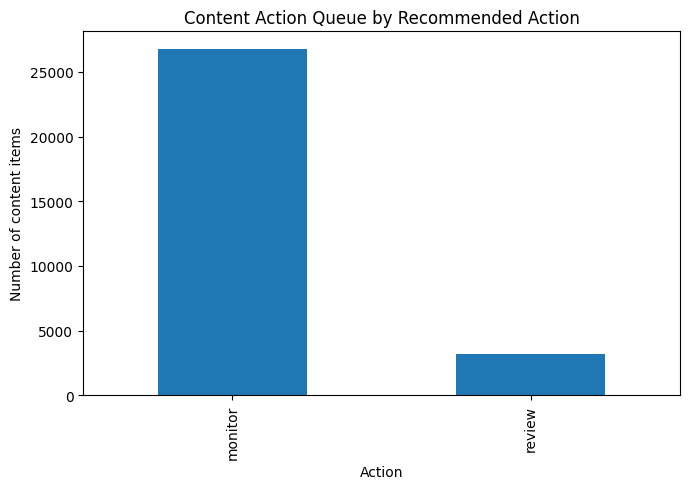

Saved figure to: ../figures/action_queue_by_action.png


In [81]:
import matplotlib.pyplot as plt

action_counts = action_queue["action"].value_counts()

plt.figure(figsize=(7, 5))
action_counts.plot(kind="bar")

plt.xlabel("Action")
plt.ylabel("Number of content items")
plt.title("Content Action Queue by Recommended Action")

plt.tight_layout()

# Save figure to work/figures/
figure_path = Path("../figures/action_queue_by_action.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure to: {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- ✅ Every section above is filled — markdown thinking AND the code that backs it
- ✅ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✅ No client names, URLs, or private queries anywhere
- ✅ My claims use careful words: observed, measured, directional, decision-support
- ✅ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.